In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import joblib

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
sns.set(style='whitegrid')

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
#загрузим датасеты
sessions = pd.read_csv('/content/drive/MyDrive/ga_sessions.csv')
hits = pd.read_csv('/content/drive/MyDrive/ga_hits.csv')

print(sessions.shape)
print(hits.shape)

display(sessions.head())
display(hits.head())

/tmp/ipykernel_2018/1697331879.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  sessions = pd.read_csv('/content/drive/MyDrive/ga_sessions.csv')


(1860042, 18)
(15726470, 11)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [4]:
#проверим колонки и типы данных
print('ga_sessions columns:')
print(sessions.columns.tolist())

print('\nga_hits columns:')
print(hits.columns.tolist())

print('\nga_sessions info:')
sessions.info()

print('\nga_hits info:')
hits.info()

ga_sessions columns:
['session_id', 'client_id', 'visit_date', 'visit_time', 'visit_number', 'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 'utm_keyword', 'device_category', 'device_os', 'device_brand', 'device_model', 'device_screen_resolution', 'device_browser', 'geo_country', 'geo_city']

ga_hits columns:
['session_id', 'hit_date', 'hit_time', 'hit_number', 'hit_type', 'hit_referer', 'hit_page_path', 'event_category', 'event_action', 'event_label', 'event_value']

ga_sessions info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8 

In [5]:
#найдем ключ объединения
common_cols = list(set(sessions.columns).intersection(set(hits.columns)))
print('Общие колонки:', common_cols)

Общие колонки: ['session_id']


In [6]:
#уникальные идентификаторы
for col in sessions.columns:
    if 'id' in col.lower():
        print('sessions:', col, sessions[col].nunique())

for col in hits.columns:
    if 'id' in col.lower():
        print('hits:', col, hits[col].nunique())

sessions: session_id 1860042
sessions: client_id 1391717
hits: session_id 1734610


In [7]:
#собираем target
target_actions = [
    'sub_car_claim_click',
    'sub_car_claim_submit_click',
    'sub_open_dialog_click',
    'sub_call_number_click',
    'sub_callback_submit_click'
]

In [8]:
hits['event_action'].value_counts().head(50)

,count
event_action,
view_card,3558985
view_new_card,3551009
sub_landing,1798117
go_to_car_card,973666
sub_view_cars_click,791515
search_form_region,512069
search_form_search_btn,433748
sap_search_form_cost_to,356596
showed_number_ads,326274


In [9]:
hits['is_target'] = hits['event_action'].isin(target_actions).astype(int)

target_by_session = hits.groupby('session_id')['is_target'].max().reset_index()

display(target_by_session.head())
print(target_by_session['is_target'].value_counts(normalize=True))

,session_id,is_target
0,1000009318903347362.1632663668.1632663668,0
1,1000010177899156286.1635013443.1635013443,0
2,1000013386240115915.1635402956.1635402956,0
3,1000017303238376207.1623489300.1623489300,0
4,1000020580299877109.1624943350.1624943350,0


is_target
0    0.971613
1    0.028387
Name: proportion, dtype: float64


In [10]:
merged = sessions.merge(target_by_session, on='session_id', how='left')
merged['is_target'] = merged['is_target'].fillna(0).astype(int)

EDA

In [11]:
#пропуски и дубликаты
def missing_table(df):
    return pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_share': df.isna().mean()
    }).sort_values('missing_share', ascending=False)

print('sessions missing:')
display(missing_table(sessions).head(20))

print('hits missing:')
display(missing_table(hits).head(20))

print('sessions duplicates:', sessions.duplicated().sum())
print('hits duplicates:', hits.duplicated().sum())

sessions missing:


,missing_count,missing_share
device_model,1843704,0.991216
utm_keyword,1082061,0.581740
device_os,1070138,0.575330
device_brand,367178,0.197403
utm_adcontent,335615,0.180434
utm_campaign,219603,0.118063
utm_source,97,0.000052
session_id,0,0.000000
client_id,0,0.000000
visit_number,0,0.000000


hits missing:


,missing_count,missing_share
event_value,15726470,1.000000
hit_time,9160322,0.582478
hit_referer,6274804,0.398996
event_label,3760184,0.239099
hit_number,0,0.000000
hit_date,0,0.000000
session_id,0,0.000000
hit_type,0,0.000000
event_category,0,0.000000
hit_page_path,0,0.000000


sessions duplicates: 0
hits duplicates: 0


In [12]:
#удалим дубликаты
sessions = sessions.drop_duplicates().copy()
hits = hits.drop_duplicates().copy()

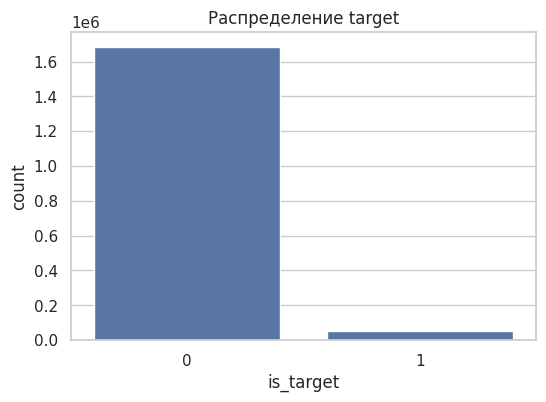

In [13]:
#визуализируем
plt.figure(figsize=(6,4))
sns.countplot(x='is_target', data=target_by_session if 'target_by_session' in globals() else hits)
plt.title('Распределение target')
plt.show()

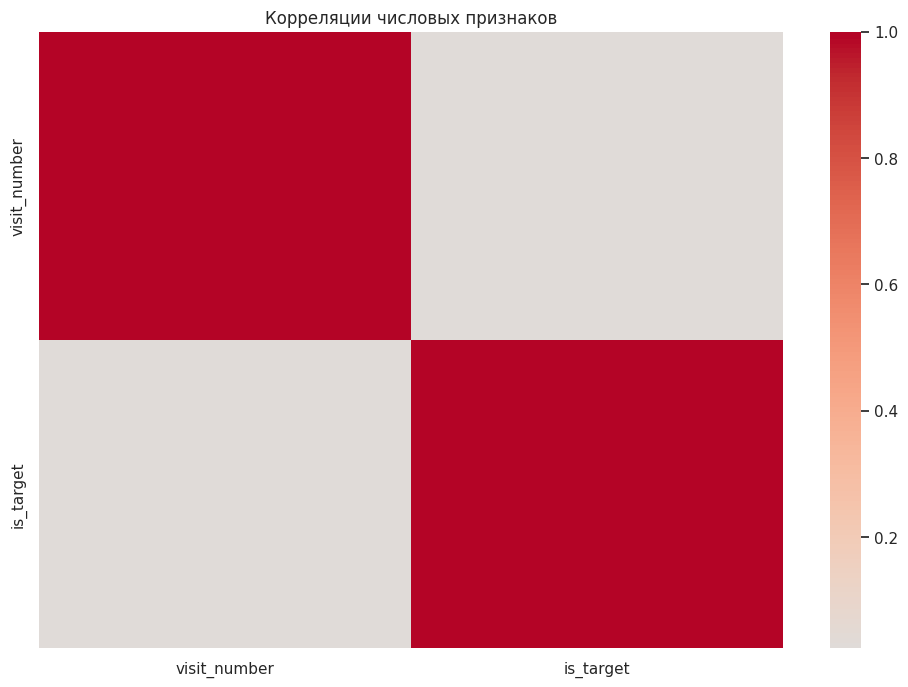

In [14]:
num_cols = merged.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12, 8))
sns.heatmap(merged[num_cols].corr(), cmap='coolwarm', center=0)
plt.title('Корреляции числовых признаков')
plt.show()

Создадим признаки

In [15]:
df = merged.copy()

date_col = 'visit_date' if 'visit_date' in df.columns else None
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df['hour'] = df[date_col].dt.hour
    df['dayofweek'] = df[date_col].dt.dayofweek
    df['month'] = df[date_col].dt.month

In [16]:

for col in ['utm_source', 'utm_medium', 'utm_campaign', 'device_category', 'geo_city']:
    if col in df.columns:
        df[col] = df[col].fillna('unknown').astype(str)

In [17]:
if 'hit_page_path' in df.columns:
    df['page_depth'] = df['hit_page_path'].astype(str).str.count('/')

In [18]:
if 'session_duration' in df.columns and 'hits_count' in df.columns:
    df['duration_per_hit'] = df['session_duration'] / (df['hits_count'] + 1)

Обучение baseline

In [19]:
target = 'is_target'
drop_cols = [target]
X = df.drop(columns=drop_cols)
y = df[target]

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

for col in cat_cols:
    X[col] = X[col].fillna('unknown').astype(str)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])

baseline = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

baseline.fit(X_train, y_train)
pred_proba = baseline.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, pred_proba)
print('Baseline ROC-AUC:', auc)

Baseline ROC-AUC: 0.7082846061331683


In [ ]:
екйва6

In [20]:
#проверим случайный лес
rf = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced_subsample'
    ))
])

rf.fit(X_train, y_train)
pred_proba_rf = rf.predict_proba(X_valid)[:, 1]
auc_rf = roc_auc_score(y_valid, pred_proba_rf)
print('RandomForest ROC-AUC:', auc_rf)

RandomForest ROC-AUC: 0.6357077952740763


Вывод: baseline-модель оказалась лучше RandomForest и уже даёт хороший результат, требуемый заданием

In [21]:
#сохранение модели  интерференс
best_model = baseline

joblib.dump(best_model, 'model.pkl')

['model.pkl']

In [24]:
import os
print(os.path.exists('model.pkl'))
print(os.path.getsize('model.pkl'))

True
112290746


In [25]:
joblib.dump(baseline, '/content/drive/MyDrive/model.pkl')

['/content/drive/MyDrive/model.pkl']

In [22]:
loaded_model = joblib.load('model.pkl')


In [23]:
import joblib
import pandas as pd

model = joblib.load('model.pkl')

def predict(df: pd.DataFrame):
    proba = model.predict_proba(df)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return pred, proba